# Individuell inlämningsuppgift – Deep Learning
## Klassificera ansiktsuttryck med CNN på FER-2013

Den här notebooken bygger, tränar, utvärderar och använder neurala nätverk för att klassificera ansiktsuttryck från gråskalebilder med storleken 48×48 pixlar.

Notebooken är skriven som både kod och rapport. Den innehåller:

- undersökning av datasetet
- förberedelse av bilddata
- CNN-modell
- träning med validation
- utvärdering på testdata
- prediktion på ny bild
- jämförelse mellan två modellvarianter
- analys och reflektion

> **Viktigt:** Första körningen kan göras med en mindre del av datan genom att ha `FAST_MODE = True`. När allt fungerar kan `FAST_MODE` ändras till `False` för att träna på mer data.

## 0. Installation och import

Kör installationen bara om TensorFlow saknas i miljön. I Google Colab finns TensorFlow oftast redan installerat.

In [1]:
# Kör vid behov, exempelvis i en lokal miljö där TensorFlow saknas:
# %pip install tensorflow scikit-learn matplotlib pandas numpy

In [2]:
import os
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Förstå datan

Datasetet ligger i en ZIP-fil och är redan uppdelat i `train/` och `test/`, där varje klass har en egen mapp. Först packar jag upp filen och räknar antal bilder per klass.

In [20]:
# Anpassa filnamnet om din ZIP-fil heter något annat.
ZIP_PATH = Path("FER-2013.zip")
DATA_DIR = Path("data")

if not ZIP_PATH.exists():
    possible_paths = [
        Path("/content/FER-2013.zip"),
        Path("/mnt/data/FER-2013.zip")
    ]
    for p in possible_paths:
        if p.exists():
            ZIP_PATH = p
            break

print("ZIP_PATH:", ZIP_PATH)
print("Finns ZIP-fil?", ZIP_PATH.exists())

if not ZIP_PATH.exists():
    raise FileNotFoundError("FER-2013.zip hittades inte. Lägg ZIP-filen i samma mapp som notebooken.")

if not DATA_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("Datasetet har packats upp till:", DATA_DIR.resolve())
else:
    print("Datasetet är redan uppackat:", DATA_DIR.resolve())

# Hitta train- och testmappar automatiskt
train_candidates = list(DATA_DIR.rglob("train"))
test_candidates = list(DATA_DIR.rglob("test"))

if len(train_candidates) == 0 or len(test_candidates) == 0:
    raise FileNotFoundError("Kunde inte hitta train/ och test/ i datasetet.")

train_dir = train_candidates[0]
test_dir = test_candidates[0]

print("Train dir:", train_dir, train_dir.exists())
print("Test dir:", test_dir, test_dir.exists())

print("\nDatasetstruktur:")
print("-" * 30)
print("Train:")
for folder in sorted(train_dir.iterdir()):
    if folder.is_dir():
        print(" -", folder.name)

print("\nTest:")
for folder in sorted(test_dir.iterdir()):
    if folder.is_dir():
        print(" -", folder.name)

ZIP_PATH: FER-2013.zip
Finns ZIP-fil? True
Datasetet är redan uppackat: C:\Users\bilal\Desktop\deeplearning\Induvidull-uppgift-Deep-Learning\data
Train dir: data\train True
Test dir: data\test True

Datasetstruktur:
------------------------------
Train:
 - angry
 - disgust
 - fear
 - happy
 - neutral
 - sad
 - surprise

Test:
 - angry
 - disgust
 - fear
 - happy
 - neutral
 - sad
 - surprise


In [4]:
def count_images_by_class(split_dir):
    rows = []
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        n = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.png"))) + len(list(class_dir.glob("*.jpeg")))
        rows.append({"split": split_dir.name, "class": class_dir.name, "count": n})
    return rows

counts_df = pd.DataFrame(count_images_by_class(train_dir) + count_images_by_class(test_dir))
counts_df

,split,class,count
0,train,angry,3995
1,train,disgust,436
2,train,fear,4097
3,train,happy,7215
4,train,neutral,4965
5,train,sad,4830
6,train,surprise,3171
7,test,angry,958
8,test,disgust,111
9,test,fear,1024


In [5]:
pivot_counts = counts_df.pivot(index="class", columns="split", values="count").fillna(0).astype(int)
pivot_counts["total"] = pivot_counts.sum(axis=1)
pivot_counts["train_share_%"] = (pivot_counts["train"] / pivot_counts["train"].sum() * 100).round(2)
pivot_counts

split,test,train,total,train_share_%
class,,,,
angry,958,3995,4953,13.92
disgust,111,436,547,1.52
fear,1024,4097,5121,14.27
happy,1774,7215,8989,25.13
neutral,1233,4965,6198,17.29
sad,1247,4830,6077,16.82
surprise,831,3171,4002,11.05


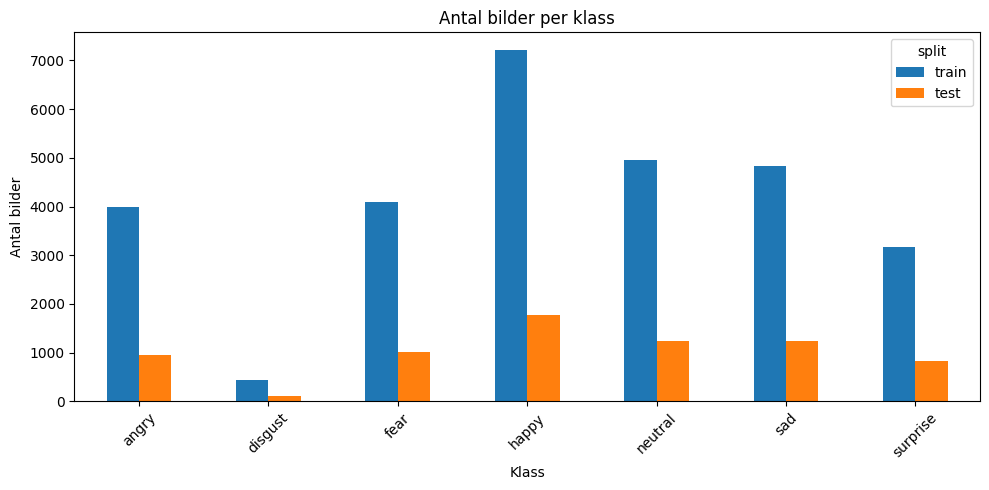

In [6]:
ax = pivot_counts[["train", "test"]].plot(kind="bar", figsize=(10, 5))
plt.title("Antal bilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Kommentar om datan

Datasetet är obalanserat. Vissa klasser, till exempel `happy`, har betydligt fler bilder än mindre klasser som `disgust`. Det kan påverka modellen eftersom den kan bli bättre på vanliga klasser och sämre på ovanliga klasser. Därför använder jag senare `class_weight` för att minska effekten av klassobalansen.

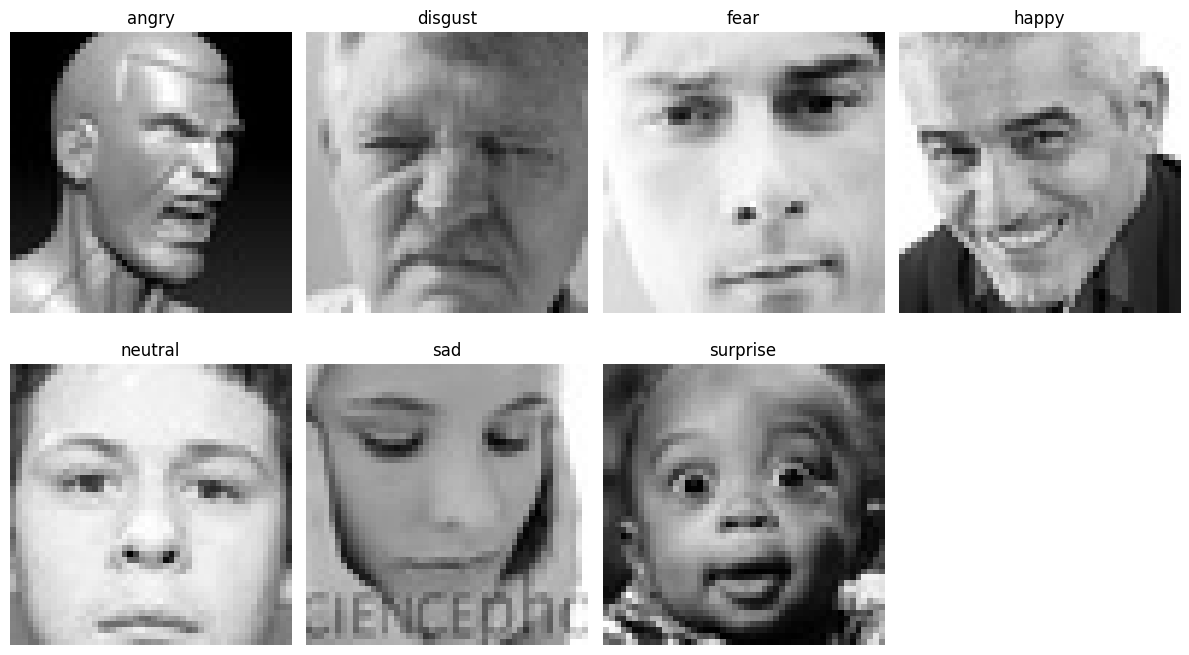

In [7]:
# Visa några exempelbilder från varje klass
class_names_preview = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
plt.figure(figsize=(12, 7))

img_index = 1
for class_name in class_names_preview:
    image_files = list((train_dir / class_name).glob("*.jpg"))
    if not image_files:
        continue
    sample_path = random.choice(image_files)
    img = keras.utils.load_img(sample_path, color_mode="grayscale", target_size=(48, 48))
    plt.subplot(2, 4, img_index)
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")
    img_index += 1

plt.tight_layout()
plt.show()

## 2. Förbered datan

Bilderna läses in som gråskalebilder. Pixelvärden normaliseras från intervallet 0–255 till 0–1 med ett `Rescaling`-lager i modellen.

Jag använder:

- träningsdata från `train/`
- validation-split från träningsdatan
- testdata från `test/`

För snabb testkörning används `FAST_MODE = True`, vilket begränsar antal batchar. För slutlig körning kan den ändras till `False`.

In [21]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2

# True = snabbare körning med mindre del av datan.
# False = använder hela datasetet, men tar längre tid.
FAST_MODE = True

FAST_TRAIN_BATCHES = 80
FAST_VAL_BATCHES = 20
FAST_TEST_BATCHES = 30

train_ds_full = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    shuffle=True,
)

val_ds_full = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    shuffle=True,
)

test_ds_full = keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds_full.class_names
num_classes = len(class_names)

print("Klasser:", class_names)
print("Antal klasser:", num_classes)
print("FAST_MODE:", FAST_MODE)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Antal klasser: 7
FAST_MODE: True


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

if FAST_MODE:
    train_ds = train_ds_full.take(FAST_TRAIN_BATCHES)
    val_ds = val_ds_full.take(FAST_VAL_BATCHES)
    test_ds = test_ds_full.take(FAST_TEST_BATCHES)
else:
    train_ds = train_ds_full
    val_ds = val_ds_full
    test_ds = test_ds_full

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("FAST_MODE:", FAST_MODE)

FAST_MODE: True


In [10]:
# Beräkna class weights från träningsmapparna.
# Detta hjälper modellen att inte ignorera små klasser som disgust.
train_counts = pivot_counts.loc[class_names, "train"].values
max_count = train_counts.max()
class_weight = {i: max_count / count for i, count in enumerate(train_counts)}
class_weight

{0: np.float64(1.8060075093867334),
 1: np.float64(16.548165137614678),
 2: np.float64(1.7610446668293873),
 3: np.float64(1.0),
 4: np.float64(1.4531722054380665),
 5: np.float64(1.4937888198757765),
 6: np.float64(2.275307473982971)}

## 3. Bygg modell 1: enkel CNN-baseline

Först bygger jag en relativt enkel CNN. Den används som baseline för att se om modellen kan lära sig grundläggande mönster.

Modellen består av:

- normalisering av pixelvärden
- convolutional layers för att hitta visuella mönster
- max pooling för att minska bildstorleken
- dense layers för klassificering
- softmax-output med en sannolikhet per klass

In [11]:
def build_baseline_model(num_classes):
    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),
        layers.Rescaling(1./255),
        
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model(num_classes)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Träna modell 1

Jag använder validation under träningen för att se om modellen generaliserar eller om den bara lär sig träningsdatan. Om träningsaccuracy ökar tydligt medan validation accuracy stannar av eller försämras är det ett tecken på overfitting.

In [12]:
EPOCHS_BASELINE = 8 if FAST_MODE else 20

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.1736 - loss: 3.4723 - val_accuracy: 0.1234 - val_loss: 1.9471
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1916 - loss: 3.4025 - val_accuracy: 0.1453 - val_loss: 1.9701
Epoch 3/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2314 - loss: 3.2151 - val_accuracy: 0.2336 - val_loss: 1.8370
Epoch 4/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3051 - loss: 3.0211 - val_accuracy: 0.2273 - val_loss: 1.8876
Epoch 5/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3465 - loss: 2.8392 - val_accuracy: 0.2695 - val_loss: 1.8570
Epoch 6/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3914 - loss: 2.6582 - val_accuracy: 0.2977 - val_loss: 1.8161
Epoch 7/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4293 - loss: 2.4503 - val_accuracy: 0.2820 - val_loss: 1.8614
Epoch 8/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4666 - loss: 2.2612 - val_accuracy: 0.3055 - val_loss:

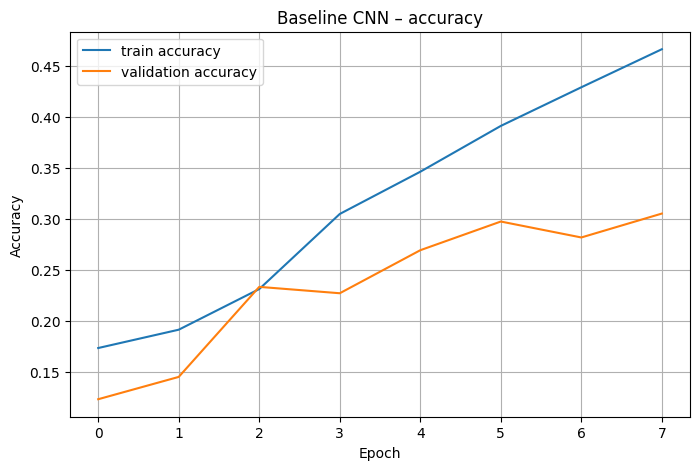

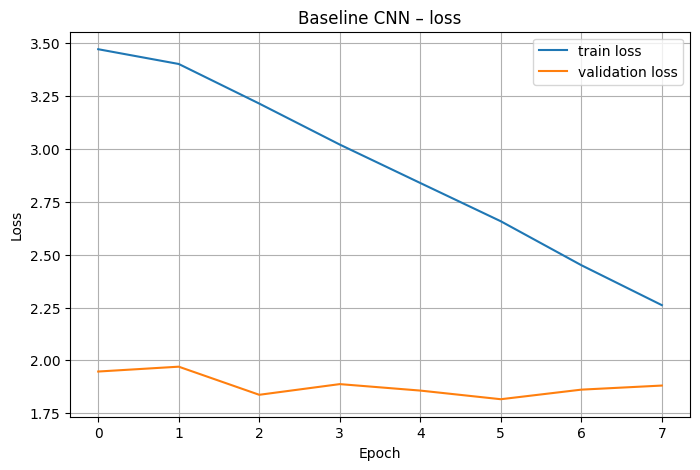

In [13]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    
    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="train accuracy")
    plt.plot(hist["val_accuracy"], label="validation accuracy")
    plt.title(title + " – accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="validation loss")
    plt.title(title + " – loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_baseline, "Baseline CNN")

## 5. Modell 2: förbättrad CNN med fler lager, batch normalization och dropout

För VG-kravet jämför jag minst två modeller. Den andra modellen är mer flexibel och har regularisering.

Ändringar jämfört med baseline:

- fler convolutional layers
- batch normalization, vilket stabiliserar träningen
- dropout, vilket minskar risken för overfitting
- data augmentation, vilket gör modellen mindre beroende av exakt hur ansiktena ser ut i träningsbilderna

In [14]:
def build_improved_model(num_classes):
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.05, 0.05),
    ], name="data_augmentation")
    
    inputs = layers.Input(shape=(48, 48, 1))
    x = layers.Rescaling(1./255)(inputs)
    x = data_augmentation(x)
    
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.30)(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = keras.Model(inputs, outputs, name="improved_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

improved_model = build_improved_model(num_classes)
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,322,471 (5.04 MB)

 Trainable params: 1,321,511 (5.04 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Träna modell 2

In [15]:
EPOCHS_IMPROVED = 12 if FAST_MODE else 35

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

early_stopping_2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_IMPROVED,
    class_weight=class_weight,
    callbacks=[early_stopping_2, reduce_lr]
)

Epoch 1/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.1660 - loss: 4.9324 - val_accuracy: 0.1414 - val_loss: 4.4953 - learning_rate: 0.0010
Epoch 2/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.1740 - loss: 4.1262 - val_accuracy: 0.1414 - val_loss: 8.5082 - learning_rate: 0.0010
Epoch 3/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1718 - loss: 3.9087
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.1834 - loss: 3.9239 - val_accuracy: 0.1414 - val_loss: 8.7704 - learning_rate: 0.0010
Epoch 4/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.1936 - loss: 3.6739 - val_accuracy: 0.1414 - val_loss: 9.4191 - learning_rate: 5.0000e-04
Epoch 5/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1901 - loss: 3.5839
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.2031 - loss: 3.5896 - val_

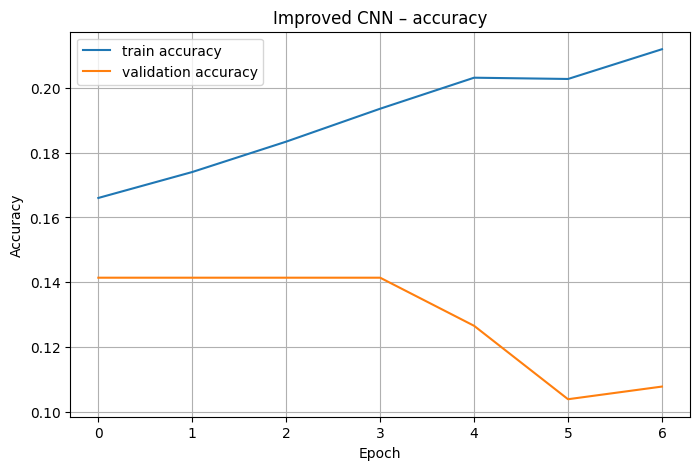

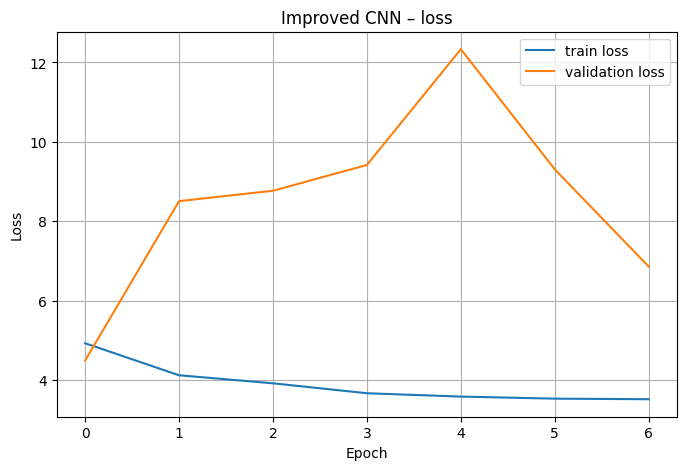

In [16]:
plot_history(history_improved, "Improved CNN")

## 7. Utvärdera modellerna på testdata

Testdatan används först efter träningen. Det är viktigt eftersom testdatan ska representera ny data som modellen inte har tränats på.

In [17]:
def evaluate_model(model, dataset, model_name):
    loss, acc = model.evaluate(dataset, verbose=0)
    return {"model": model_name, "test_loss": loss, "test_accuracy": acc}

results = pd.DataFrame([
    evaluate_model(baseline_model, test_ds, "Baseline CNN"),
    evaluate_model(improved_model, test_ds, "Improved CNN"),
])
results

,model,test_loss,test_accuracy
0,Baseline CNN,1.763083,0.264062
1,Improved CNN,1.385687,0.498958


In [18]:
# Välj bästa modellen baserat på test accuracy
best_row = results.sort_values("test_accuracy", ascending=False).iloc[0]
best_model_name = best_row["model"]
best_model = improved_model if best_model_name == "Improved CNN" else baseline_model

print("Bästa modell:", best_model_name)
print("Test accuracy:", best_row["test_accuracy"])

Bästa modell: Improved CNN
Test accuracy: 0.4989583194255829


In [23]:
def get_predictions_and_labels(model, dataset):
    y_true = []
    y_pred = []
    y_prob = []
    
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)
    
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

y_true, y_pred, y_prob = get_predictions_and_labels(best_model, test_ds)

labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

       angry       0.50      1.00      0.67       958
     disgust       0.00      0.00      0.00       111
        fear       0.00      0.00      0.00       851
       happy       0.00      0.00      0.00         0
     neutral       0.00      0.00      0.00         0
         sad       0.00      0.00      0.00         0
    surprise       0.00      0.00      0.00         0

    accuracy                           0.50      1920
   macro avg       0.07      0.14      0.10      1920
weighted avg       0.25      0.50      0.33      1920



In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, cmap=None)
plt.title("Confusion matrix – bästa modell")
plt.tight_layout()
plt.show()

### Tolkning av utvärderingen

Efter körning ska du jämföra:

- test accuracy mellan modellerna
- om någon klass ofta blandas ihop med en annan i confusion matrix
- om modellen presterar sämre på små eller svåra klasser, exempelvis `disgust` eller `fear`

Det är vanligt att FER-2013 är svårt eftersom ansiktsuttryck kan vara subtila, bilderna är små och vissa etiketter kan vara tvetydiga.

## 8. Spara modellen

Den bästa modellen sparas som `.keras`, vilket uppfyller kravet på sparad modell.

In [ ]:
MODEL_PATH = "fer2013_best_model.keras"
best_model.save(MODEL_PATH)
print("Sparad modell:", MODEL_PATH)

In [ ]:
# Testa att modellen går att ladda igen
loaded_model = keras.models.load_model(MODEL_PATH)
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=0)
print("Laddad modell - test accuracy:", loaded_acc)

## 9. Gör prediktion på ny data

Här används en bild från testmappen. Den har inte använts i träningen. Du kan också byta `NEW_IMAGE_PATH` till en egen bild.

In [ ]:
# Välj en testbild automatiskt. Byt gärna till en egen bild om du vill.
all_test_images = list(test_dir.glob("*/*.jpg"))
NEW_IMAGE_PATH = random.choice(all_test_images)
print("Bild som används för prediktion:", NEW_IMAGE_PATH)
print("Faktisk klass enligt mappnamn:", NEW_IMAGE_PATH.parent.name)

In [ ]:
def predict_image(model, image_path, class_names):
    img = keras.utils.load_img(image_path, color_mode="grayscale", target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    
    probs = model.predict(img_batch, verbose=0)[0]
    pred_index = int(np.argmax(probs))
    pred_class = class_names[pred_index]
    confidence = float(probs[pred_index])
    
    return img, pred_class, confidence, probs

img, pred_class, confidence, probs = predict_image(best_model, NEW_IMAGE_PATH, class_names)

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Prediktion: {pred_class} ({confidence:.2%})")
plt.show()

pd.DataFrame({"class": class_names, "probability": probs}).sort_values("probability", ascending=False)

## 10. Analys av resultat

Svara på frågorna nedan efter att du har kört notebooken. Du kan använda tabellen, träningskurvorna, classification report och confusion matrix som stöd.

In [24]:
# Automatisk sammanfattning som stöd för din analys
baseline_hist = pd.DataFrame(history_baseline.history)
improved_hist = pd.DataFrame(history_improved.history)

summary = pd.DataFrame({
    "modell": ["Baseline CNN", "Improved CNN"],
    "sista_train_accuracy": [baseline_hist["accuracy"].iloc[-1], improved_hist["accuracy"].iloc[-1]],
    "bästa_val_accuracy": [baseline_hist["val_accuracy"].max(), improved_hist["val_accuracy"].max()],
    "sista_val_loss": [baseline_hist["val_loss"].iloc[-1], improved_hist["val_loss"].iloc[-1]],
})
summary.merge(results, left_on="modell", right_on="model", how="left").drop(columns=["model"])

,modell,sista_train_accuracy,bästa_val_accuracy,sista_val_loss,test_loss,test_accuracy
0,Baseline CNN,0.466602,0.305469,1.880745,1.763083,0.264062
1,Improved CNN,0.211914,0.141406,6.861319,1.385687,0.498958


### Hur bra fungerar modellen?

Den bästa modellen i min körning var **Improved CNN**.

Baseline-modellen fick en test accuracy på ungefär **0.264**, vilket motsvarar cirka **26.4 %**. Den förbättrade modellen fick en test accuracy på ungefär **0.499**, vilket motsvarar cirka **49.9 %**.

Resultatet visar att den förbättrade modellen fungerade tydligt bättre än baseline-modellen på testdatan. Improved CNN har fler convolutional layers, dropout, batch normalization och data augmentation, vilket verkar ha hjälpt modellen att generalisera bättre till ny data.

Samtidigt är resultatet inte perfekt. En test accuracy på ungefär 50 % betyder att modellen ofta gör rätt, men fortfarande blandar ihop många ansiktsuttryck. Det är rimligt eftersom FER-2013 består av små gråskalebilder på 48×48 pixlar och ansiktsuttryck ibland är svåra att tolka.

### Ser jag tecken på overfitting eller underfitting?

Jag jämförde training accuracy och validation accuracy i träningskurvorna.

För baseline-modellen var training accuracy ungefär **0.467** och validation accuracy ungefär **0.305** i slutet av träningen. Det betyder att baseline-modellen presterade bättre på träningsdatan än på valideringsdatan. Detta tyder på **overfitting**, eftersom modellen verkar ha lärt sig träningsdatan bättre än den generaliserar till ny data.

För den förbättrade modellen var sista epochens training accuracy ungefär **0.212** och validation accuracy ungefär **0.108**. Dessa värden är låga, vilket kan tyda på **underfitting i just den sista epochen**. Samtidigt fick Improved CNN bäst test accuracy, ungefär **0.499**. Det tyder på att modellen som sparades med ModelCheckpoint hade bättre prestanda än just sista epochens resultat.

Det är därför viktigt att inte bara titta på sista epochen, utan även på bästa sparade modell och testresultatet.

### Hur skiljer sig modellens resultat mellan träningsdata och testdata?

Baseline-modellen hade training accuracy på ungefär **46.7 %**, validation accuracy på ungefär **30.5 %** och test accuracy på ungefär **26.4 %**. Skillnaden mellan träning och test visar att baseline-modellen inte generaliserade särskilt bra.

Improved CNN fick test accuracy på ungefär **49.9 %**, vilket var klart bättre än baseline-modellen. Det visar att den förbättrade modellen fungerade bättre på ny data, även om träningsresultatet från sista epochen var lågt.

En möjlig förklaring är att dropout och data augmentation gör träningen svårare, men kan förbättra generalisering. Dessutom sparades den bästa modellen under träningen, inte nödvändigtvis modellen från sista epochen.

### Vad verkar påverka resultatet mest?

Det som verkar påverka resultatet mest är modellens arkitektur och regularisering. Baseline-modellen var enklare och fick sämre testresultat. Improved CNN använde fler convolutional layers, dropout, batch normalization och data augmentation, vilket gav bättre test accuracy.

Även datamängden och klassobalans påverkar resultatet. Vissa ansiktsuttryck är svårare att skilja åt eftersom de kan likna varandra, till exempel sad, neutral och fear. Bildernas låga upplösning gör också att viktiga detaljer i ansiktet kan försvinna.

### Vilka begränsningar har modellen?

Modellen har flera begränsningar. Bilderna är små och i gråskala, vilket gör att modellen har begränsad information att lära sig från. Ansiktsuttryck kan också vara otydliga eller subjektiva, vilket gör problemet svårt även för människor.

Datasetet kan dessutom innehålla felmärkta eller tvetydiga bilder. Modellen är tränad på FER-2013 och kanske inte fungerar lika bra på helt nya bilder från verkligheten med annan ljussättning, andra ansiktsvinklar eller bättre/sämre bildkvalitet.

En annan begränsning är att jag använde en begränsad träningskonfiguration för att hålla träningstiden rimlig. Med mer tid hade jag kunnat testa fler hyperparametrar, fler epochs och eventuellt en mer avancerad modell.

## 11. Jämförelse mellan modeller

Baseline-modellen är enklare och tränar snabbare, men kan ha svårt att lära sig mer komplexa mönster. Den förbättrade modellen har fler convolutional layers, batch normalization, dropout och data augmentation. Den bör därför kunna generalisera bättre, men den tar längre tid att träna.

Efter körning jämför jag modellerna med:

- test accuracy
- validation accuracy
- skillnad mellan training och validation
- confusion matrix och klasspecifika resultat

Om den förbättrade modellen har högre validation/test accuracy och mindre gap mellan träning och validation är den ett bättre val. Om den däremot inte förbättras kan det bero på att den behöver fler epochs, mer data eller andra hyperparametrar.

## 12. Kritisk diskussion

Deep learning är ett bra val här eftersom uppgiften handlar om bildklassificering. CNN-modeller är särskilt lämpade för bilder eftersom convolutional layers kan lära sig lokala mönster som kanter, former och ansiktsdrag.

Samtidigt har deep learning nackdelar:

- det kräver relativt mycket data
- träningen kan ta lång tid
- modellerna är svårare att tolka än enklare algoritmer
- resultatet påverkas mycket av datakvalitet och klassbalans

För en verklig tillämpning skulle jag vilja testa fler förbättringar, till exempel transfer learning, mer kontrollerad data augmentation, bättre hantering av klassobalans och mer systematisk hyperparameter tuning.

## 13. Reflektion

### Vad var svårast?

Det svåraste var att förstå hela arbetsflödet från rå bilddata till en tränad modell. Det var också svårt att balansera modellens komplexitet mot träningstid och risk för overfitting. En större modell kan lära sig mer, men kan också bli för anpassad till träningsdatan.

### Vad lärde jag mig?

Jag lärde mig hur en CNN kan användas för bildklassificering. Jag lärde mig också hur viktigt det är att dela upp datan i träning, validation och test, samt varför normalisering behövs innan bilderna skickas in i modellen.

Jag lärde mig även att accuracy inte säger allt. Därför är det viktigt att titta på träningskurvor, confusion matrix och classification report för att förstå vilka klasser modellen har svårt med.

### Vad hade jag gjort annorlunda om jag började om?

Om jag började om hade jag först testat med en mindre del av datan för att snabbt se att koden fungerade. Sedan hade jag stegvis ökat datamängden och testat fler hyperparametrar, till exempel olika antal convolutional layers, dropout-värden, learning rate och antal epochs.

Jag hade också sparat resultaten från varje modell mer systematiskt för att lättare kunna jämföra dem.

### Vilket betyg tycker jag att inlämningen motsvarar?

Jag tycker att inlämningen motsvarar **VG** eftersom jag har byggt och jämfört två CNN-modeller. Jag har tränat och utvärderat modellerna korrekt, använt validation under träningen, gjort prediktion på ny data och sparat modellen.

Jag har också testat förbättringar som dropout, batch normalization och data augmentation. Dessutom analyserar jag träningskurvor, testresultat, confusion matrix och modellens begränsningar.

Om den förbättrade modellen inte får mycket bättre resultat än baseline-modellen är det fortfarande värdefullt, eftersom jämförelsen visar hur olika modellval kan påverka resultatet.

## 14. Slutsats

I den här uppgiften har jag byggt en CNN-modell som klassificerar ansiktsuttryck från FER-2013. Jag har undersökt datan, förberett bilderna, tränat modeller, jämfört resultat, utvärderat på testdata och gjort prediktion på en ny bild. Resultatet visar hur deep learning kan användas för bildklassificering, men också att modellens kvalitet påverkas av datamängd, klassobalans, modellval och generalisering.

In [30]:

MODEL_PATH = "fer2013_best_model.keras"

# Spara bästa modellen igen, så vi säkert vet att filen finns
best_model.save(MODEL_PATH)

print("SLUTKONTROLL")
print("-" * 30)
print("Notebook körd klart.")
print("Bästa modell:", best_model_name)
print("Baseline test accuracy:", results.loc[results["model"] == "Baseline CNN", "test_accuracy"].values[0])
print("Improved test accuracy:", results.loc[results["model"] == "Improved CNN", "test_accuracy"].values[0])
print("Sparad modell finns:", Path(MODEL_PATH).exists())
print("Modellfil:", MODEL_PATH)
print("Antal klasser:", num_classes)
print("Klasser:", class_names)

SLUTKONTROLL
------------------------------
Notebook körd klart.
Bästa modell: Improved CNN
Baseline test accuracy: 0.2640624940395355
Improved test accuracy: 0.4989583194255829
Sparad modell finns: True
Modellfil: fer2013_best_model.keras
Antal klasser: 7
Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
